# Figure S8 — Chamber-contribution decomposition of Figure 8D

Per-chamber decomposition where each chamber panel cell value is the fraction
of the group's **total** frames (across all chambers) spent in that
(cluster × chamber). With this normalization the three chamber panels sum
cell-wise to the pooled panel:

$$\text{Pooled}[c, g] = \text{Stranger}[c, g] + \text{Middle}[c, g] + \text{Novel}[c, g]$$

Row and column order is fixed by average-linkage Euclidean clustering on the
pooled matrix (same ordering as Figure 8D). Color scale shared across all
four panels.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_context("notebook")
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import leaves_list, linkage

# Use Arial across all figures (publication consistency)
plt.rcParams['font.family'] = 'Arial'


In [2]:
EXPERIMENTAL_GROUPS = ["NS", "Hx", "LPS", "DH"]
CUSTOM_GROUP_LABELS = ["Sal-N", "Sal-Hx", "LPS-N", "LPS-Hx"]
BSOID_LABELS = list(range(14))

def _load(name):
    df = pd.read_csv(f"data/{name}.csv", index_col=0)
    df.columns = EXPERIMENTAL_GROUPS
    return df

pooled    = _load("contrib_pooled")
stranger  = _load("contrib_stranger_mouse_chamber")
middle    = _load("contrib_middle_chamber")
novel     = _load("contrib_novel_object_chamber")

recon = stranger + middle + novel
max_err = float(np.abs(pooled.values - recon.values).max())
print(f"Additivity check max |pooled - sum(chambers)| = {max_err:.2e}")


Additivity check max |pooled - sum(chambers)| = 2.22e-16


In [3]:
# Y-axis: keep dendrogram-derived row order so behaviour clusters
# that move together stack together.
# X-axis: drop the column dendrogram entirely and force the natural
# manuscript group order (Sal-N -> Sal-Hx -> LPS-N -> LPS-Hx).
row_link  = linkage(pooled.values, method='average', metric='euclidean')
row_order = leaves_list(row_link)
col_order = list(range(len(EXPERIMENTAL_GROUPS)))    # natural order

def reorder(m):
    return m.iloc[row_order, col_order]

pooled_r   = reorder(pooled)
stranger_r = reorder(stranger)
middle_r   = reorder(middle)
novel_r    = reorder(novel)

custom_labels_reord  = [CUSTOM_GROUP_LABELS[i] for i in col_order]
cluster_labels_reord = [BSOID_LABELS[i]        for i in row_order]
vmax = float(pooled_r.values.max())


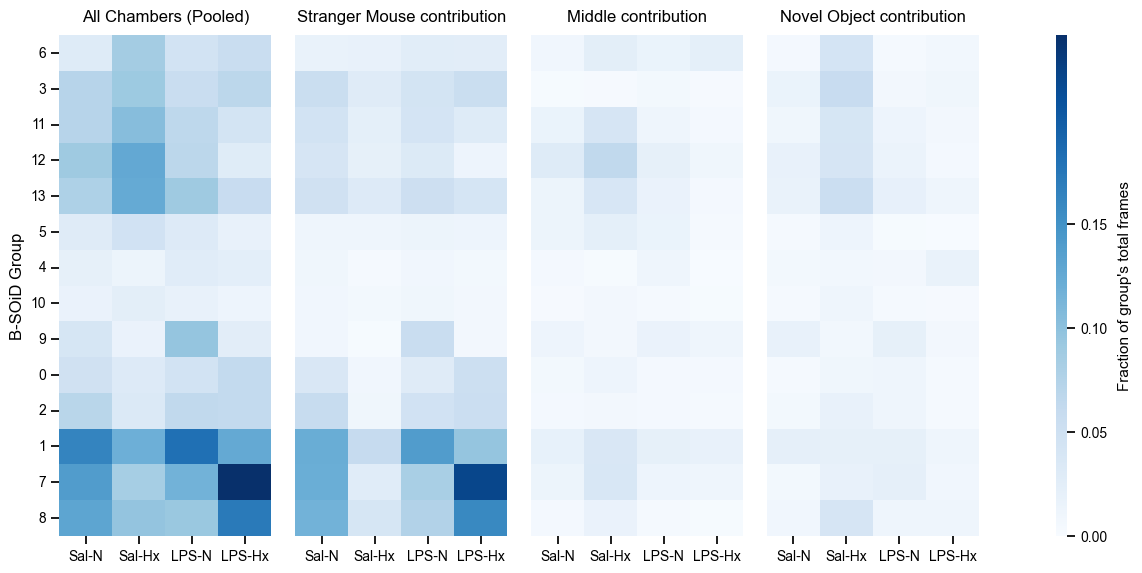

In [4]:
# Narrow per-cell width: figure aspect tall instead of wide.
# Colorbar pushed firmly outside the 4 heatmap panels so it doesn't
# overlap any data.
fig = plt.figure(figsize=(13, 6.5), facecolor='white')
gs = gridspec.GridSpec(
    1, 6,
    width_ratios=[1.0, 1.0, 1.0, 1.0, 0.14, 0.05],
    wspace=0.16,
)
ax_pool = fig.add_subplot(gs[0, 0])
ax_str  = fig.add_subplot(gs[0, 1])
ax_mid  = fig.add_subplot(gs[0, 2])
ax_nov  = fig.add_subplot(gs[0, 3])
ax_cb   = fig.add_subplot(gs[0, 5])

def heatmap(ax, mat, title, show_y=False, show_cbar=False):
    sns.heatmap(
        mat, ax=ax, cmap='Blues', vmin=0, vmax=vmax,
        cbar=show_cbar, cbar_ax=ax_cb if show_cbar else None,
        xticklabels=custom_labels_reord,
        yticklabels=cluster_labels_reord if show_y else False,
        linewidths=0, rasterized=False,
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('B-SOiD Group' if show_y else '')
    plt.setp(ax.get_xticklabels(), fontsize=10, rotation=0)
    plt.setp(ax.get_yticklabels(), fontsize=10, rotation=0)
    if show_cbar:
        ax_cb.set_yticks([0.0, 0.05, 0.10, 0.15])
        plt.setp(ax_cb.get_yticklabels(), fontsize=10)

heatmap(ax_pool, pooled_r,   'All Chambers (Pooled)', show_y=True)
heatmap(ax_str,  stranger_r, 'Stranger Mouse contribution')
heatmap(ax_mid,  middle_r,   'Middle contribution')
heatmap(ax_nov,  novel_r,    'Novel Object contribution', show_cbar=True)
ax_cb.set_ylabel("Fraction of group's total frames", fontsize=11, labelpad=8)
plt.setp(ax_cb.get_yticklabels(), fontsize=10)

fig.savefig('FigS8.png', dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig('FigS8.pdf',          bbox_inches='tight', facecolor='white')
plt.show()


**Reading the figure.** For any cluster × group cell, the three chamber
panels decompose the pooled value into chamber contributions. For example,
cluster 8 in LPS-Hx (≈ 0.19 pooled) is dominated by the Stranger Mouse
contribution (≈ 0.13), with smaller Novel Object (≈ 0.05) and Middle (≈ 0.01)
components — the Stranger chamber carries almost the entire signal because
mice spend most of their time there.
